# 제조업 실시간 이상탐지: PaDiM · AutoEncoder · One-Class SVM

강사 노트북을 그대로 한 번 돌린 뒤(셀 위쪽), 맨 아래에 **[실험 1]\~[실험 10]** 셀을 추가했다.
실험마다 **돌리기 전에 적은 내 예측 → 결과 → 해석**을 셀 바로 아래에 남겼다.
요약은 레포의 `README.md`, 실험별 상세는 `analysis.md`에 있다.

| 발견 | 숫자 |
| --- | --- |
| AutoEncoder 0.265는 출력 범위(Sigmoid 0\~1) 고장 | Sigmoid 제거 시 0.928 |
| 학습 때 좌우 뒤집기는 정상 범위를 넓혀 불량을 숨김 | PaDiM 0.958→0.974, SVM 0.817→0.872 |
| Gradio 판정 기준 15는 정상 사진의 67%를 불량 판정 | 정상 점수 중앙값 17.6 |

### 이상탐지를 위한 라이브러리 설치

In [ ]:
!pip install anomalib
!pip install pytorch-lightning

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.2/800.2 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 57.8 MB/s eta 0:00:00
  Created wheel for freia: filename=freia-0.2-py3-none-any.whl size=42848 sha256=3b22410af5afd8d4c49371c1d884fe70fe7cd0170c2b5ce019369a636b238c24
  Stored in direc

In [ ]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9686 sha256=5af250104b36ef86a121062b526dcd60e199566f8e14981c202e8c8fc06b5301
  Stored in directory: /root/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget


## VisA 데이터셋 다운로드

In [ ]:
import os
import wget
import zipfile
from pathlib import Path
import pandas as pd
import tarfile

def download_visa_dataset():
    """VisA 데이터셋 다운로드"""
    base_url = "https://amazon-visual-anomaly.s3.us-west-2.amazonaws.com/VisA_20220922.tar"
    filename = "VisA_20220922.tar"
    extract_dir = "./VisA"


    if not os.path.exists(filename):
        print("VisA 데이터셋 다운로드 중...")
        wget.download(base_url, filename)
        print("\n다운로드 완료!")

    ## 압축 해제
    if not os.path.exists(extract_dir):
        os.makedirs(extract_dir, exist_ok=True)
        with tarfile.open(filename, 'r') as tar:
            tar.extractall(path=extract_dir)
        print("압축 해제 완료!")

def check_visa_structure(data_path="./VisA_pytorch/VisA"):
    """VisA 데이터셋 구조 확인"""
    data_path = Path(data_path)
    print(f"VisA 데이터셋 경로: {data_path}")

    categories = []
    for category_dir in data_path.iterdir():
        if category_dir.is_dir():
            categories.append(category_dir.name)
            print(f"\n카테고리: {category_dir.name}")

            # 이미지 개수 확인
            images_dir = category_dir / "Data" / "Images"
            if images_dir.exists():
                normal_count = len(list((images_dir / "Normal").glob("*"))) if (images_dir / "Normal").exists() else 0


                print(f"  정상 이미지: {normal_count}개")

    return categories

In [ ]:
download_visa_dataset()

VisA 데이터셋 다운로드 중...

다운로드 완료!


/tmp/ipykernel_2516/1396103325.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


압축 해제 완료!


In [ ]:
check_visa_structure(data_path="./VisA")

VisA 데이터셋 경로: VisA

카테고리: split_csv

카테고리: pipe_fryum
  정상 이미지: 500개

카테고리: capsules
  정상 이미지: 602개

카테고리: macaroni2
  정상 이미지: 1000개

카테고리: pcb2
  정상 이미지: 1001개

카테고리: candle
  정상 이미지: 1000개

카테고리: fryum
  정상 이미지: 500개

카테고리: macaroni1
  정상 이미지: 1000개

카테고리: chewinggum
  정상 이미지: 503개

카테고리: pcb3
  정상 이미지: 1006개

카테고리: pcb4
  정상 이미지: 1005개

카테고리: cashew
  정상 이미지: 500개

카테고리: pcb1
  정상 이미지: 1004개


['split_csv',
 'pipe_fryum',
 'capsules',
 'macaroni2',
 'pcb2',
 'candle',
 'fryum',
 'macaroni1',
 'chewinggum',
 'pcb3',
 'pcb4',
 'cashew',
 'pcb1']

### Dataloader 구현

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import cv2
import numpy as np

class VisADataset(Dataset):
    def __init__(self, data_path, category, transform=None, is_train=True, include_mask=False, train_ratio=0.8):
        self.data_path = Path(data_path)
        self.category = category
        self.transform = transform
        self.is_train = is_train
        self.include_mask = include_mask

        self.image_paths = []
        self.mask_paths = []
        self.labels = []
        self.defect_types = []

        category_path = self.data_path / category

        # CSV 파일에서 메타데이터 로드
        csv_path = category_path / "image_anno.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            print(f"CSV 컬럼: {df.columns.tolist()}")

            # 정상/비정상 데이터 분리
            normal_df = df[df['label'] == 'normal'].copy()
            anomaly_df = df[df['label'] != 'normal'].copy()

            if self.is_train:
                # 훈련용: 정상 데이터의 일부만 사용
                train_size = int(len(normal_df) * train_ratio)
                selected_df = normal_df.iloc[:train_size]
                print(f"훈련용 정상 데이터: {len(selected_df)}개")
            else:
                # 테스트용: 나머지 정상 데이터 + 모든 비정상 데이터
                test_normal_size = len(normal_df) - int(len(normal_df) * train_ratio)
                test_normal_df = normal_df.iloc[-test_normal_size:] if test_normal_size > 0 else pd.DataFrame()
                selected_df = pd.concat([test_normal_df, anomaly_df], ignore_index=True)
                print(f"테스트용 정상 데이터: {len(test_normal_df)}개")
                print(f"테스트용 비정상 데이터: {len(anomaly_df)}개")

            # 데이터 로드
            for _, row in selected_df.iterrows():
                # 이미지 경로 처리 (중복 경로 제거)
                image_rel_path = row['image']
                if image_rel_path.startswith(category + '/'):
                    image_path = self.data_path / image_rel_path
                else:
                    image_path = category_path / image_rel_path

                if image_path.exists():
                    self.image_paths.append(str(image_path))
                    self.labels.append(0 if row['label'] == 'normal' else 1)
                    self.defect_types.append(row['label'])

                    # 마스크 경로 처리
                    if pd.notna(row['mask']) and self.include_mask:
                        mask_rel_path = row['mask']
                        if mask_rel_path.startswith(category + '/'):
                            mask_path = self.data_path / mask_rel_path
                        else:
                            mask_path = category_path / mask_rel_path
                        self.mask_paths.append(str(mask_path) if mask_path.exists() else None)
                    else:
                        self.mask_paths.append(None)
                else:
                    print(f"이미지 파일을 찾을 수 없습니다: {image_path}")
        else:
            print("CSV 파일이 없습니다. 폴더 구조를 기반으로 데이터를 로드합니다.")
            self._load_from_folder_structure()

    def _load_from_folder_structure(self):
        """폴더 구조를 기반으로 데이터 로드 (CSV가 없는 경우)"""
        category_path = self.data_path / self.category
        images_path = category_path / "Data" / "Images"
        masks_path = category_path / "Data" / "Masks"

        if self.is_train:
            # 훈련용: 정상 이미지만 사용
            normal_path = images_path / "Normal"
            if normal_path.exists():
                for img_path in normal_path.glob("*"):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        self.image_paths.append(str(img_path))
                        self.labels.append(0)  # 정상: 0
                        self.defect_types.append('normal')
                        self.mask_paths.append(None)
        else:
            # 테스트용: 정상 + 비정상 이미지
            # 정상 이미지
            normal_path = images_path / "Normal"
            if normal_path.exists():
                for img_path in normal_path.glob("*"):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        self.image_paths.append(str(img_path))
                        self.labels.append(0)
                        self.defect_types.append('normal')
                        self.mask_paths.append(None)

            # 비정상 이미지
            anomaly_path = images_path / "Anomaly"
            if anomaly_path.exists():
                for img_path in anomaly_path.glob("*"):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        self.image_paths.append(str(img_path))
                        self.labels.append(1)  # 이상: 1
                        self.defect_types.append('anomaly')

                        # 마스크 경로 찾기
                        if self.include_mask:
                            mask_name = img_path.stem + '.png'  # 확장자를 png로 변경
                            mask_path = masks_path / "Anomaly" / mask_name
                            self.mask_paths.append(str(mask_path) if mask_path.exists() else None)
                        else:
                            self.mask_paths.append(None)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 이미지 로드
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        # 마스크 로드 (있는 경우)
        mask = None
        if self.include_mask and self.mask_paths[idx] is not None:
            try:
                mask = Image.open(self.mask_paths[idx]).convert('L')
            except:
                mask = None

        # 변환 적용
        if self.transform:
            image = self.transform(image)
            if mask is not None:
                mask_transform = transforms.Compose([
                    transforms.Resize((256, 256)),
                    transforms.ToTensor()
                ])
                mask = mask_transform(mask)

        result = {
            'image': image,
            'label': label,
            'defect_type': self.defect_types[idx]
        }

        if mask is not None:
            result['mask'] = mask

        return result

In [ ]:
# 데이터 전처리 정의
def get_visa_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    return train_transform, test_transform


In [ ]:
def create_visa_data_loaders(data_path, category, batch_size=32, include_mask=False, train_ratio=0.8):
    """
    VisA 데이터셋용 데이터 로더 생성

    Args:
        data_path: VisA 데이터셋 경로
        category: 카테고리 이름
        batch_size: 배치 크기
        include_mask: 마스크 포함 여부
        train_ratio: 훈련 데이터 비율 (정상 데이터에서)
    """
    train_transform, test_transform = get_visa_transforms()

    train_dataset = VisADataset(
        data_path, category,
        transform=train_transform,
        is_train=True,
        include_mask=include_mask,
        train_ratio=train_ratio
    )

    test_dataset = VisADataset(
        data_path, category,
        transform=test_transform,
        is_train=False,
        include_mask=include_mask,
        train_ratio=train_ratio
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,  # Windows에서 문제가 있을 수 있으므로 낮춤
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, test_loader


## 시각화

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

def visualize_visa_samples(dataset, num_samples=8):
    """VisA 데이터셋 샘플 시각화"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    for i, idx in enumerate(indices):
        sample = dataset[idx]
        image = sample['image']
        label = sample['label']
        defect_type = sample['defect_type']

        # 텐서를 이미지로 변환
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0)
            image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
            image = torch.clamp(image, 0, 1)

        axes[i].imshow(image)
        title = f"{'Normal' if label == 0 else 'Anomaly'}"
        if defect_type != 'normal':
            title += f"\n({defect_type})"
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def visualize_with_mask(dataset, idx):
    """이미지와 마스크 함께 시각화"""
    sample = dataset[idx]
    image = sample['image']
    mask = sample.get('mask')
    label = sample['label']
    defect_type = sample['defect_type']

    # 이미지 정규화 해제
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0)
        image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        image = torch.clamp(image, 0, 1)

    if mask is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # 원본 이미지
        axes[0].imshow(image)
        axes[0].set_title('Original Image')
        axes[0].axis('off')

        # 마스크
        axes[1].imshow(mask.squeeze(), cmap='gray')
        axes[1].set_title('Anomaly Mask')
        axes[1].axis('off')

        # 오버레이
        overlay = image.clone()
        if mask.sum() > 0:
            mask_resized = torch.nn.functional.interpolate(
                mask.unsqueeze(0),
                size=image.shape[:2],
                mode='nearest'
            ).squeeze()
            overlay[mask_resized > 0.01] = torch.tensor([255.0, 0.0, 0.0])  # 빨간색으로 표시

        axes[2].imshow(overlay)
        axes[2].set_title(f'Overlay ({defect_type})')
        axes[2].axis('off')

    else:
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.title(f"{'Normal' if label == 0 else 'Anomaly'} - {defect_type}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_visa_statistics(data_path, category):
    """VisA 데이터셋 통계 시각화"""
    category_path = Path(data_path) / category
    csv_path = category_path / "image_anno.csv"

    if csv_path.exists():
        df = pd.read_csv(csv_path)

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        title1 = 'Overall Class Distribution (Normal vs Anomaly)'
        title2 = 'Main Defect Types Distribution'
        title3 = 'Mask Availability Distribution'
        title4 = 'All Labels Distribution (Top 10)'
        xlabel2 = 'Number of Images'
        ylabel3 = 'Number of Images'
        xlabel4 = 'Number of Images'
        mask_labels = ['With Mask', 'Without Mask']

        # 전체 클래스 분포 (정상 vs 비정상)
        binary_labels = ['Normal' if label == 'normal' else 'Anomaly' for label in df['label']]
        class_counts = pd.Series(binary_labels).value_counts()
        axes[0, 0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%')
        axes[0, 0].set_title(title1)

        # 결함 유형별 상세 분포
        anomaly_df = df[df['label'] != 'normal']
        if not anomaly_df.empty:
            # 결함 유형을 단순화 (콤마로 구분된 경우 첫 번째만 사용)
            simplified_defects = [label.split(',')[0] for label in anomaly_df['label']]
            defect_counts = pd.Series(simplified_defects).value_counts()

            axes[0, 1].barh(defect_counts.index, defect_counts.values)
            axes[0, 1].set_title(title2)
            axes[0, 1].set_xlabel(xlabel2)

        # 마스크 유무 분포
        mask_counts = df['mask'].notna().value_counts()
        mask_labels_mapped = [mask_labels[0] if has_mask else mask_labels[1] for has_mask in mask_counts.index]
        axes[1, 0].bar(mask_labels_mapped, mask_counts.values)
        axes[1, 0].set_title(title3)
        axes[1, 0].set_ylabel(ylabel3)

        # 전체 결함 유형 (복합 결함 포함)
        all_defect_counts = df['label'].value_counts()
        # 상위 10개만 표시
        top_defects = all_defect_counts.head(10)
        axes[1, 1].barh(range(len(top_defects)), top_defects.values)
        axes[1, 1].set_yticks(range(len(top_defects)))
        axes[1, 1].set_yticklabels(top_defects.index)
        axes[1, 1].set_title(title4)
        axes[1, 1].set_xlabel(xlabel4)

        plt.tight_layout()
        plt.show()

        # 데이터 요약 출력

        print(f"Total images: {len(df)}")
        print(f"Normal images: {len(df[df['label'] == 'normal'])}")
        print(f"Anomaly images: {len(df[df['label'] != 'normal'])}")
        print(f"Images with masks: {df['mask'].notna().sum()}")
        print(f"Unique defect types: {df['label'].nunique()}")

    else:
        error_msg = f"CSV 파일을 찾을 수 없습니다: {csv_path}" if KOREAN_FONT_AVAILABLE else f"CSV file not found: {csv_path}"
        print(error_msg)


In [ ]:
DATA_PATH = "./VisA" # <--- 실제 데이터셋 경로로 변경하세요!
CATEGORY_NAME = "pcb4" # VisA 데이터셋의 카테고리 중 하나 (예: 'pcb', 'capsules' 등)
BATCH_SIZE = 8 # 메모리에 따라 조절
D_REDUCED = 100 # PaDiM의 축소된 특징 차원
IMG_SIZE = 256  # 입력 이미지 크기 (예시)
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]
# PaDiM 내부에서 특징맵을 리사이즈할 크기 (고정)
PADIM_PATCH_SIZE = 28

train_loader, test_loader = create_visa_data_loaders(DATA_PATH, CATEGORY_NAME, BATCH_SIZE, include_mask=True)

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개


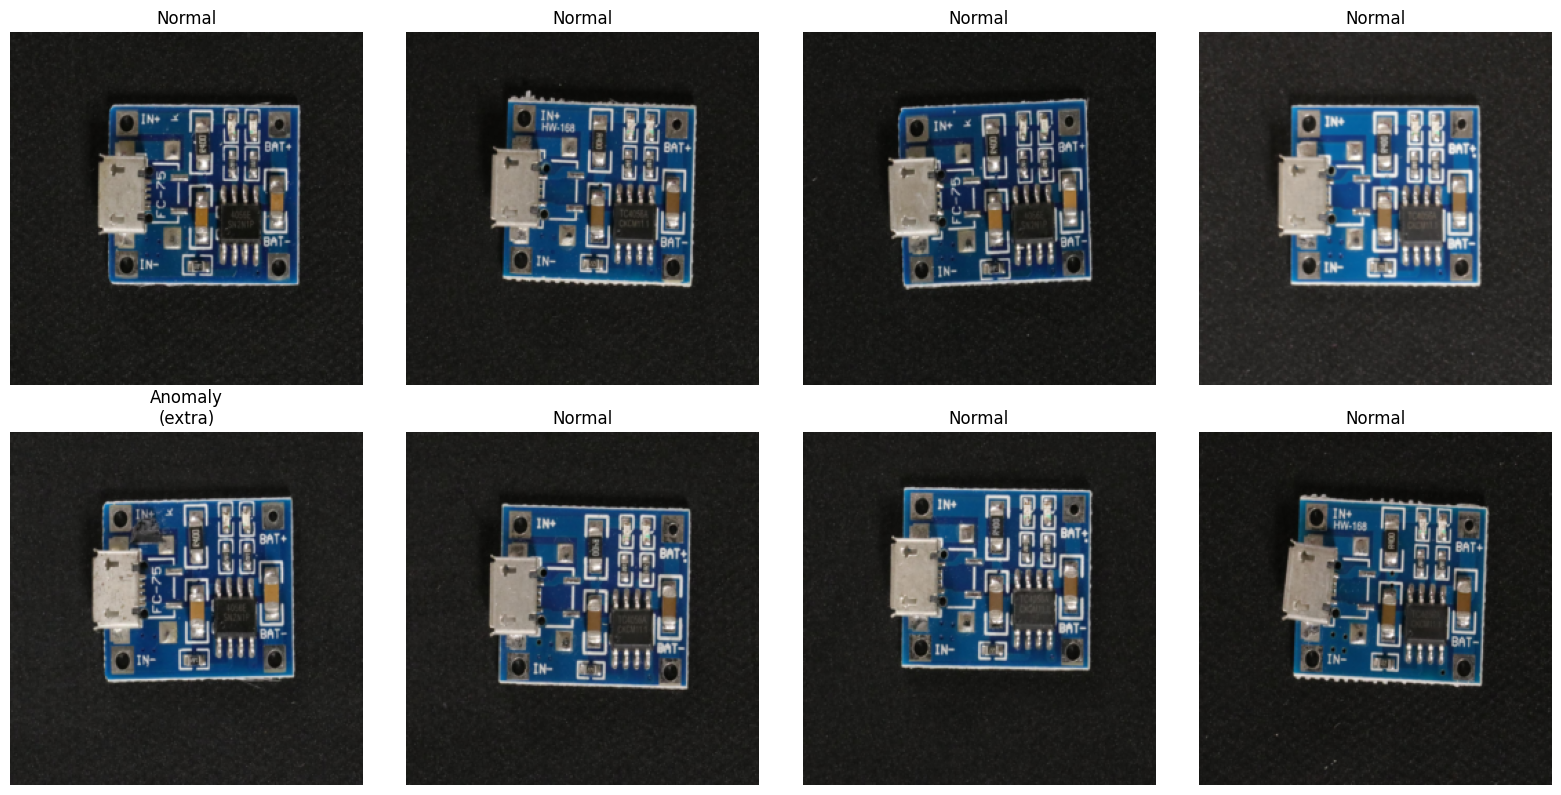

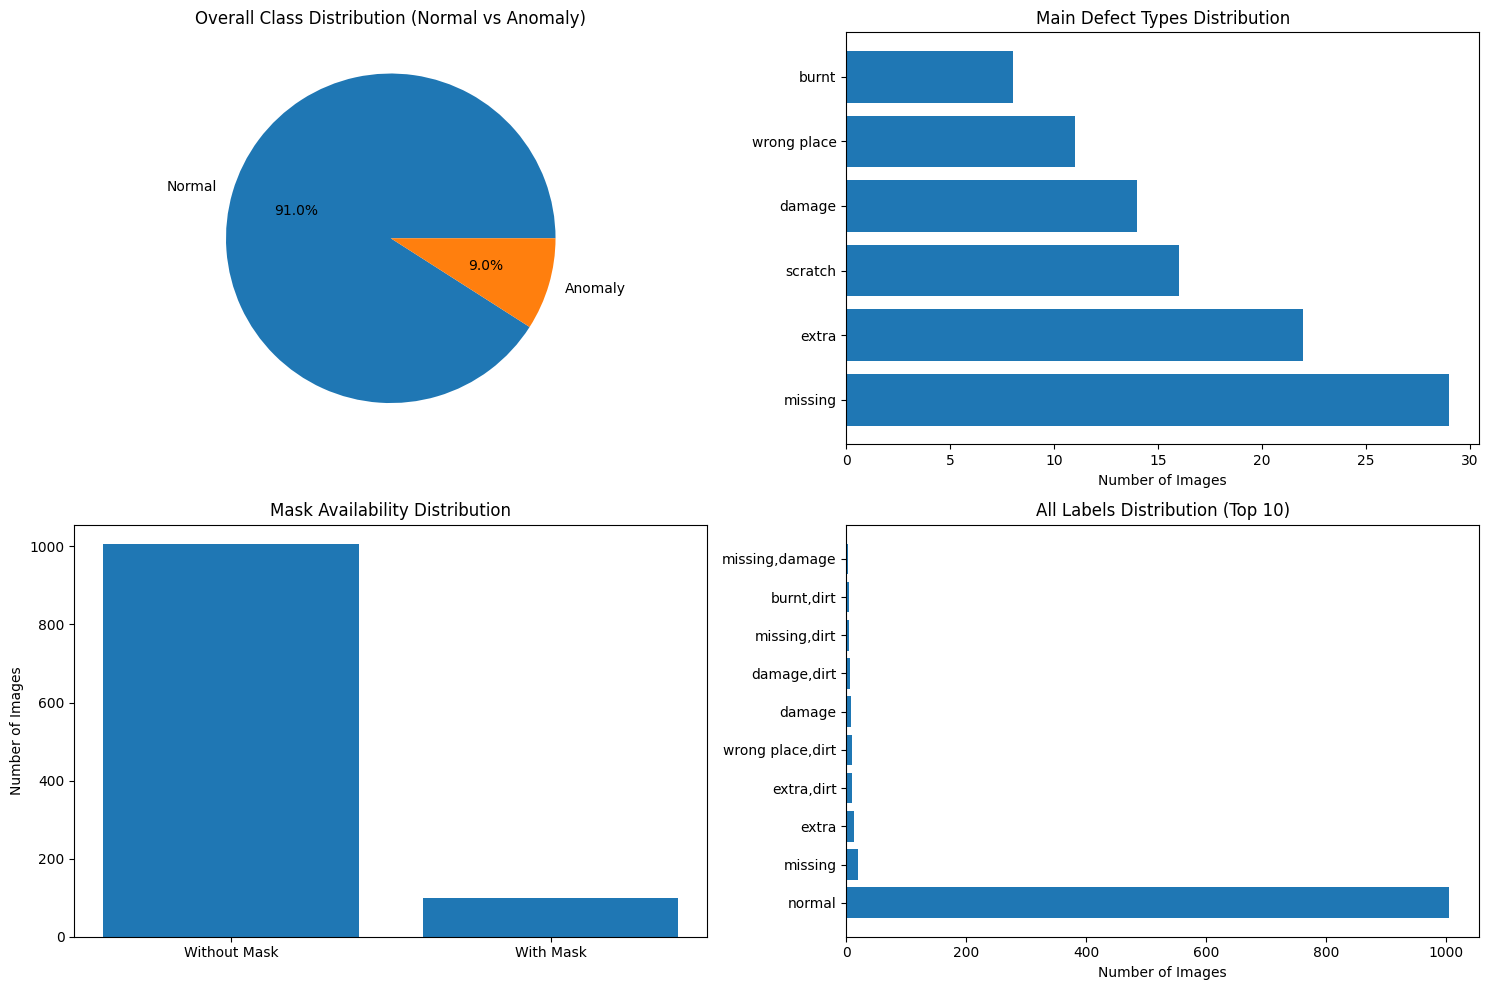

Total images: 1105
Normal images: 1005
Anomaly images: 100
Images with masks: 100
Unique defect types: 27


In [ ]:
visualize_visa_samples(test_loader.dataset)
plot_visa_statistics(DATA_PATH, CATEGORY_NAME)

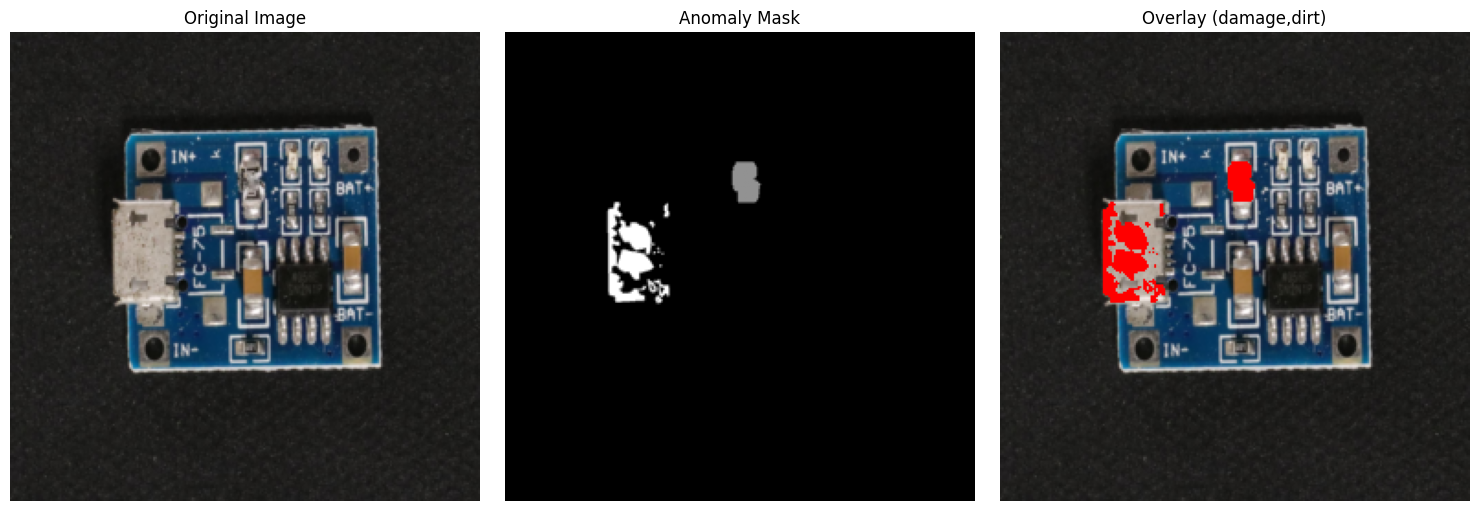

In [ ]:
visualize_with_mask(test_loader.dataset, 210)

## 모델 구현

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

import cv2
from PIL import Image
from pathlib import Path
import pickle
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")


사용 장치: cuda


In [ ]:
class FeatureExtractor(nn.Module):
    def __init__(self, model_name='resnet18', layers_to_extract=['layer1', 'layer2', 'layer3']):
        super(FeatureExtractor, self).__init__()

        if model_name == 'resnet18':
            self.model = models.resnet18(pretrained=True)
        elif model_name == 'resnet50':
            self.model = models.resnet50(pretrained=True)
        elif model_name == 'wide_resnet50':
            self.model = models.wide_resnet50_2(pretrained=True)
        else:
            raise ValueError(f"지원하지 않는 모델: {model_name}")

        self.layers_to_extract = layers_to_extract
        self.features = {}

        # Hook 등록
        for name, module in self.model.named_modules():
            if name in layers_to_extract:
                module.register_forward_hook(self.save_features(name))

        # 평가 모드로 설정
        self.model.eval()

        # 그래디언트 계산 비활성화
        for param in self.model.parameters():
            param.requires_grad = False

    def save_features(self, name):
        def hook(module, input, output):
            self.features[name] = output
        return hook

    def forward(self, x):
        self.features.clear()
        _ = self.model(x)
        return self.features

# Feature Extractor 초기화
feature_extractor = FeatureExtractor('wide_resnet50', ['layer2', 'layer3']).to(device)

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:00<00:00, 188MB/s]


### 핵심 코드 해설: PaDiM
- `all_features[patch_idx::28*28]`: 사진마다 784칸씩 순서대로 쌓여 있어서, 784줄 간격으로 뽑으면 **모든 사진의 같은 위치 칸만** 모인다. 슬라이드 p.32 "패치 위치별 다변량 정규분포"가 이 한 줄이다.
- PaDiM은 **"이 위치에는 이게 있어야 정상"이라는 위치까지 정상의 정의에 포함**한다. 그래서 학습 때 좌우 뒤집기가 해롭다(실험 4).
- 마할라노비스 거리는 공분산으로 숫자끼리의 관계를 알고 있어서, 값 하나하나는 정상인데 조합이 이상한 칸을 잡는다(실험 6).
- 사진 점수는 784칸 중 **최댓값**. 불량은 몇 칸뿐이라 평균을 내면 희석된다(실험 6).

In [ ]:
class PaDiM:
    def __init__(self, feature_extractor, d_reduced=100):
        self.feature_extractor = feature_extractor
        self.d_reduced = d_reduced
        self.means = []
        self.inv_covariances = []
        self.projection_matrix = None

    def fit(self, train_loader):
        """정상 데이터로 모델 훈련"""
        print("PaDiM 훈련 시작...")

        # 모든 훈련 데이터에서 특징 추출
        all_features = []

        for batch in tqdm(train_loader, desc="특징 추출 중"):
            images = batch['image'].to(device)

            with torch.no_grad():
                features = self.feature_extractor(images)

                # 각 이미지별로 처리
                for i in range(images.size(0)):
                    img_features = []

                    # 레이어별 특징 추출 및 결합
                    for layer_name, feat in features.items():
                        # 단일 이미지 특징 추출
                        single_feat = feat[i:i+1]  # [1, C, H, W]

                        # 28x28로 리사이즈
                        feat_resized = F.adaptive_avg_pool2d(single_feat, (28, 28))

                        # 패치별 특징으로 변환 [784, C]
                        feat_patches = feat_resized.permute(0, 2, 3, 1).reshape(28*28, -1)
                        img_features.append(feat_patches)

                    # 레이어별 특징 결합 [784, total_channels]
                    combined_features = torch.cat(img_features, dim=1)
                    all_features.append(combined_features)

        # 모든 특징을 하나로 결합 [N*784, total_channels]
        all_features = torch.cat(all_features, dim=0)
        print(f"전체 특징 크기: {all_features.shape}")

        # 차원 축소를 위한 Random Projection 행렬 생성
        if all_features.shape[1] > self.d_reduced:
            self.projection_matrix = torch.randn(all_features.shape[1], self.d_reduced).to(device)
            # 정규화
            self.projection_matrix = F.normalize(self.projection_matrix, dim=0)

            # 차원 축소 적용
            all_features = torch.mm(all_features, self.projection_matrix)
            print(f"차원 축소 후 크기: {all_features.shape}")

        # 패치 위치별로 분리하여 통계 계산
        n_samples = len(all_features) // (28 * 28)

        for patch_idx in range(28 * 28):
            # 특정 패치 위치의 모든 특징 추출
            patch_features = all_features[patch_idx::28*28]  # [n_samples, d_reduced]

            # 평균과 공분산 계산
            mean = torch.mean(patch_features, dim=0)

            # 공분산 행렬 계산 (정규화 추가)
            centered_features = patch_features - mean
            cov = torch.mm(centered_features.T, centered_features) / (patch_features.shape[0] - 1)

            # 수치 안정성을 위한 정규화
            cov += torch.eye(cov.shape[0]).to(device) * 1e-4

            # 역행렬 계산
            try:
                inv_cov = torch.linalg.inv(cov)
            except:
                # 특이행렬인 경우 pseudo-inverse 사용
                inv_cov = torch.linalg.pinv(cov)

            self.means.append(mean)
            self.inv_covariances.append(inv_cov)

        print(f"PaDiM 훈련 완료! (패치 수: {len(self.means)})")

    def predict(self, test_loader):
        """테스트 데이터에 대한 이상 점수 계산"""
        anomaly_scores = []

        for batch in tqdm(test_loader, desc="이상 탐지 중"):
            images = batch['image'].to(device)

            with torch.no_grad():
                features = self.feature_extractor(images)

                # 각 이미지별로 처리
                for i in range(images.size(0)):
                    img_features = []

                    # 레이어별 특징 추출 및 결합
                    for layer_name, feat in features.items():
                        single_feat = feat[i:i+1]
                        feat_resized = F.adaptive_avg_pool2d(single_feat, (28, 28))
                        feat_patches = feat_resized.permute(0, 2, 3, 1).reshape(28*28, -1)
                        img_features.append(feat_patches)

                    combined_features = torch.cat(img_features, dim=1)

                    # 차원 축소 (훈련 시와 동일한 방식)
                    if self.projection_matrix is not None:
                        combined_features = torch.mm(combined_features, self.projection_matrix)

                    # 각 패치별 Mahalanobis 거리 계산
                    patch_scores = []
                    for patch_idx in range(28 * 28):
                        diff = combined_features[patch_idx] - self.means[patch_idx]

                        # Mahalanobis 거리 계산
                        mahal_dist = torch.sqrt(torch.mm(
                            torch.mm(diff.unsqueeze(0), self.inv_covariances[patch_idx]),
                            diff.unsqueeze(1)
                        )).item()

                        patch_scores.append(mahal_dist)

                    # 전체 이상 점수 (최대값 사용)
                    anomaly_scores.append(max(patch_scores))

        return np.array(anomaly_scores), None

### 핵심 코드 해설: AutoEncoder (주의)
- 디코더 마지막 `nn.Sigmoid()`는 출력을 0\~1로 가둔다. 그런데 입력은 Normalize를 거쳐 약 −2.1\~+2.6이다.
- 그래서 0\~1 밖의 픽셀은 아무리 학습해도 못 그리고, 점수가 결함이 아니라 "극단 색 픽셀 양"을 재게 된다. 이 셀 결과 AUROC 0.265의 원인이다(실험 7).

In [ ]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, input_channels=3, latent_dim=128):
        super(ConvAutoEncoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, 4, stride=2, padding=1),  # 128x128
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, latent_dim, 4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(latent_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 64x64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 128x128
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, input_channels, 4, stride=2, padding=1),  # 256x256
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

class AutoEncoderAnomalyDetector:
    def __init__(self, input_size=(256, 256), latent_dim=128):
        self.model = ConvAutoEncoder(input_channels=3, latent_dim=latent_dim).to(device)
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        self.input_size = input_size

    def fit(self, train_loader, epochs=50):
        """AutoEncoder 훈련"""
        print("AutoEncoder 훈련 시작...")
        self.model.train()

        train_losses = []

        for epoch in range(epochs):
            epoch_loss = 0
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
                images = batch['image'].to(device)

                self.optimizer.zero_grad()
                reconstructed = self.model(images)
                loss = self.criterion(reconstructed, images)
                loss.backward()
                self.optimizer.step()

                epoch_loss += loss.item()

            avg_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_loss)
            print(f"Epoch {epoch+1}, Loss: {avg_loss:.6f}")

        self.model.eval()
        print("AutoEncoder 훈련 완료!")
        return train_losses

    def predict(self, test_loader):
        """테스트 데이터에 대한 재구성 오차 계산"""
        self.model.eval()
        anomaly_scores = []

        with torch.no_grad():
            for batch in tqdm(test_loader, desc="이상 탐지 중"):
                images = batch['image'].to(device)
                reconstructed = self.model(images)

                # 픽셀별 재구성 오차
                reconstruction_errors = F.mse_loss(reconstructed, images, reduction='none')
                reconstruction_errors = reconstruction_errors.view(images.size(0), -1).mean(dim=1)

                anomaly_scores.extend(reconstruction_errors.cpu().numpy())

        return np.array(anomaly_scores)

In [ ]:
class OneClassSVMAnomalyDetector:
    def __init__(self, feature_extractor, nu=0.1):
        self.feature_extractor = feature_extractor
        self.svm = OneClassSVM(nu=nu, kernel='rbf', gamma='scale')
        self.scaler = StandardScaler()

    def extract_features(self, data_loader):
        """특징 추출"""
        features = []

        for batch in tqdm(data_loader, desc="특징 추출 중"):
            images = batch['image'].to(device)

            with torch.no_grad():
                feat_dict = self.feature_extractor(images)

                # 모든 레이어의 특징을 결합하고 평균 풀링
                combined_features = []
                for layer_name, feat in feat_dict.items():
                    pooled_feat = F.adaptive_avg_pool2d(feat, (1, 1))
                    combined_features.append(pooled_feat.view(feat.size(0), -1))

                batch_features = torch.cat(combined_features, dim=1)
                features.append(batch_features.cpu().numpy())

        return np.concatenate(features, axis=0)

    def fit(self, train_loader):
        """One-Class SVM 훈련"""
        print("One-Class SVM 훈련 시작...")

        # 특징 추출
        train_features = self.extract_features(train_loader)

        # 정규화
        train_features_scaled = self.scaler.fit_transform(train_features)

        # SVM 훈련
        self.svm.fit(train_features_scaled)
        print("One-Class SVM 훈련 완료!")

    def predict(self, test_loader):
        """테스트 데이터에 대한 이상 점수 계산"""
        # 특징 추출
        test_features = self.extract_features(test_loader)

        # 정규화
        test_features_scaled = self.scaler.transform(test_features)

        # 이상 점수 계산 (결정 함수의 음수)
        anomaly_scores = -self.svm.decision_function(test_features_scaled)

        return anomaly_scores

In [ ]:
class AnomalyDetectionEvaluator:
    def __init__(self):
        self.results = {}

    def evaluate(self, y_true, y_scores, method_name):
        """평가 메트릭 계산"""
        # AUROC
        auroc = roc_auc_score(y_true, y_scores)

        # AUPRC
        precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
        auprc = auc(recall, precision)

        # 최적 임계값에서의 F1 스코어
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

        # NaN 값 제거
        valid_indices = ~np.isnan(f1_scores)
        if np.any(valid_indices):
            valid_f1_scores = f1_scores[valid_indices]
            valid_thresholds = thresholds[valid_indices] if len(thresholds) == len(f1_scores) else thresholds[:len(valid_f1_scores)]

            best_f1_idx = np.argmax(valid_f1_scores)
            best_f1 = valid_f1_scores[best_f1_idx]
            best_threshold = valid_thresholds[best_f1_idx] if len(valid_thresholds) > best_f1_idx else 0.5
        else:
            best_f1 = 0.0
            best_threshold = 0.5

        self.results[method_name] = {
            'AUROC': auroc,
            'AUPRC': auprc,
            'Best_F1': best_f1,
            'Best_Threshold': best_threshold,
            'y_true': y_true,
            'y_scores': y_scores
        }

        print(f"{method_name} 결과:")
        print(f"  AUROC: {auroc:.4f}")
        print(f"  AUPRC: {auprc:.4f}")
        print(f"  Best F1: {best_f1:.4f}")
        print()

        return auroc, auprc, best_f1

    def plot_roc_curve(self):
        """ROC 곡선 그리기"""
        plt.figure(figsize=(10, 8))

        for method_name, result in self.results.items():
            fpr, tpr, _ = roc_curve(result['y_true'], result['y_scores'])
            plt.plot(fpr, tpr, label=f"{method_name} (AUC = {result['AUROC']:.3f})")

        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves Comparison')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_precision_recall_curve(self):
        """PR 곡선 그리기"""
        plt.figure(figsize=(10, 8))

        for method_name, result in self.results.items():
            precision, recall, _ = precision_recall_curve(result['y_true'], result['y_scores'])
            plt.plot(recall, precision, label=f"{method_name} (AUC = {result['AUPRC']:.3f})")

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curves Comparison')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_score_distribution(self):
        """이상 점수 분포 시각화"""
        fig, axes = plt.subplots(len(self.results), 1, figsize=(12, 4*len(self.results)))
        if len(self.results) == 1:
            axes = [axes]

        for i, (method_name, result) in enumerate(self.results.items()):
            normal_scores = result['y_scores'][result['y_true'] == 0]
            anomaly_scores = result['y_scores'][result['y_true'] == 1]

            axes[i].hist(normal_scores, bins=50, alpha=0.7, label='Normal', density=True)
            axes[i].hist(anomaly_scores, bins=50, alpha=0.7, label='Anomaly', density=True)
            axes[i].axvline(result['Best_Threshold'], color='red', linestyle='--',
                           label=f"Best Threshold: {result['Best_Threshold']:.3f}")
            axes[i].set_title(f'{method_name} - Anomaly Score Distribution')
            axes[i].set_xlabel('Anomaly Score')
            axes[i].set_ylabel('Density')
            axes[i].legend()
            axes[i].grid(True)

        plt.tight_layout()
        plt.show()

    def compare_methods(self):
        """방법별 성능 비교"""
        methods = list(self.results.keys())
        aurocs = [self.results[m]['AUROC'] for m in methods]
        auprcs = [self.results[m]['AUPRC'] for m in methods]
        f1_scores = [self.results[m]['Best_F1'] for m in methods]

        x = np.arange(len(methods))
        width = 0.25

        plt.figure(figsize=(12, 6))
        plt.bar(x - width, aurocs, width, label='AUROC', alpha=0.8)
        plt.bar(x, auprcs, width, label='AUPRC', alpha=0.8)
        plt.bar(x + width, f1_scores, width, label='Best F1', alpha=0.8)

        plt.xlabel('Methods')
        plt.ylabel('Score')
        plt.title('Performance Comparison')
        plt.xticks(x, methods, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
class VisAAnomalyDetectionSystem:
    def __init__(self, data_path, category):
        self.data_path = data_path
        self.category = category
        self.evaluator = AnomalyDetectionEvaluator()

        # 데이터 로더 생성
        self.train_loader, self.test_loader = create_visa_data_loaders(
            data_path, category, batch_size=16, include_mask=False, train_ratio=0.8
        )

        # 테스트 레이블 추출
        self.test_labels = []
        for batch in self.test_loader:
            self.test_labels.extend(batch['label'].numpy())
        self.test_labels = np.array(self.test_labels)

        print(f"시스템 초기화 완료:")
        print(f"  카테고리: {category}")
        print(f"  훈련 데이터: {len(self.train_loader.dataset)}개")
        print(f"  테스트 데이터: {len(self.test_loader.dataset)}개")
        print(f"  테스트 중 이상 데이터: {self.test_labels.sum()}개")

    def run_padim(self):
        """PaDiM 실행"""
        print("\n=== PaDiM 실행 ===")
        padim = PaDiM(feature_extractor, d_reduced=100)
        padim.fit(self.train_loader)
        scores, _ = padim.predict(self.test_loader)
        self.evaluator.evaluate(self.test_labels, scores, 'PaDiM')
        return scores

    def run_autoencoder(self, epochs=30):
        """AutoEncoder 실행"""
        print("\n=== AutoEncoder 실행 ===")
        ae_detector = AutoEncoderAnomalyDetector()
        ae_detector.fit(self.train_loader, epochs=epochs)
        scores = ae_detector.predict(self.test_loader)
        self.evaluator.evaluate(self.test_labels, scores, 'AutoEncoder')
        return scores

    def run_ocsvm(self):
        """One-Class SVM 실행"""
        print("\n=== One-Class SVM 실행 ===")
        ocsvm_detector = OneClassSVMAnomalyDetector(feature_extractor, nu=0.1)
        ocsvm_detector.fit(self.train_loader)
        scores = ocsvm_detector.predict(self.test_loader)
        self.evaluator.evaluate(self.test_labels, scores, 'One-Class SVM')
        return scores

    def run_all_methods(self):
        """모든 방법 실행 및 비교"""
        print("모든 anomaly detection 방법을 실행합니다...")

        # 각 방법 실행 (오류가 발생해도 계속 진행)
        methods_tried = []

        # 1. AutoEncoder (가장 안정적)
        try:
            print("\n=== AutoEncoder 실행 ===")
            self.run_autoencoder(epochs=15)
            methods_tried.append("AutoEncoder")
        except Exception as e:
            print(f"AutoEncoder 실행 중 오류: {e}")

        # 2. One-Class SVM
        try:
            print("\n=== One-Class SVM 실행 ===")
            self.run_ocsvm()
            methods_tried.append("One-Class SVM")
        except Exception as e:
            print(f"One-Class SVM 실행 중 오류: {e}")

        # 3. PaDiM (메모리 사용량이 많을 수 있음)
        try:
            print("\n=== PaDiM 실행 ===")
            self.run_padim()
            methods_tried.append("PaDiM")
        except Exception as e:
            print(f"PaDiM 실행 중 오류: {e}")
            print("팁: GPU 메모리가 부족할 수 있습니다. 배치 크기를 줄여보세요.")

        # 결과 시각화
        if self.evaluator.results:
            print(f"\n=== 전체 결과 ({len(methods_tried)}개 방법 성공) ===")
            try:
                self.evaluator.compare_methods()
            except Exception as e:
                print(f"비교 차트 생성 중 오류: {e}")

            try:
                self.evaluator.plot_roc_curve()
            except Exception as e:
                print(f"ROC 곡선 생성 중 오류: {e}")

            try:
                self.evaluator.plot_precision_recall_curve()
            except Exception as e:
                print(f"PR 곡선 생성 중 오류: {e}")

            try:
                self.evaluator.plot_score_distribution()
            except Exception as e:
                print(f"점수 분포 차트 생성 중 오류: {e}")
        else:
            print("❌ 성공적으로 실행된 방법이 없습니다.")
            print("다음을 확인해보세요:")
            print("1. 데이터 경로가 올바른지 확인")
            print("2. GPU 메모리가 충분한지 확인")
            print("3. 필요한 라이브러리가 모두 설치되어 있는지 확인")

    def save_results(self, filename):
        """결과 저장"""
        results_to_save = {}
        for method, result in self.evaluator.results.items():
            results_to_save[method] = {
                'AUROC': result['AUROC'],
                'AUPRC': result['AUPRC'],
                'Best_F1': result['Best_F1'],
                'Best_Threshold': result['Best_Threshold']
            }

        with open(filename, 'w') as f:
            json.dump(results_to_save, f, indent=2)
        print(f"결과가 {filename}에 저장되었습니다.")

In [ ]:
system = VisAAnomalyDetectionSystem("./VisA", "pcb4")

# 개별 방법 실행
padim_scores = system.run_padim()
ae_scores = system.run_autoencoder(epochs=50)
svm_scores = system.run_ocsvm()


CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
시스템 초기화 완료:
  카테고리: pcb4
  훈련 데이터: 804개
  테스트 데이터: 301개
  테스트 중 이상 데이터: 100개

=== PaDiM 실행 ===
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.30it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)


이상 탐지 중: 100%|██████████| 19/19 [00:24<00:00,  1.30s/it]


PaDiM 결과:
  AUROC: 0.9575
  AUPRC: 0.8904
  Best F1: 0.8651


=== AutoEncoder 실행 ===
AutoEncoder 훈련 시작...


...

AutoEncoder 결과:
  AUROC: 0.2653
  AUPRC: 0.2261
  Best F1: 0.5249


=== One-Class SVM 실행 ===
One-Class SVM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:14<00:00,  3.45it/s]


One-Class SVM 훈련 완료!


특징 추출 중: 100%|██████████| 19/19 [00:05<00:00,  3.66it/s]


One-Class SVM 결과:
  AUROC: 0.8267
  AUPRC: 0.7165
  Best F1: 0.6693



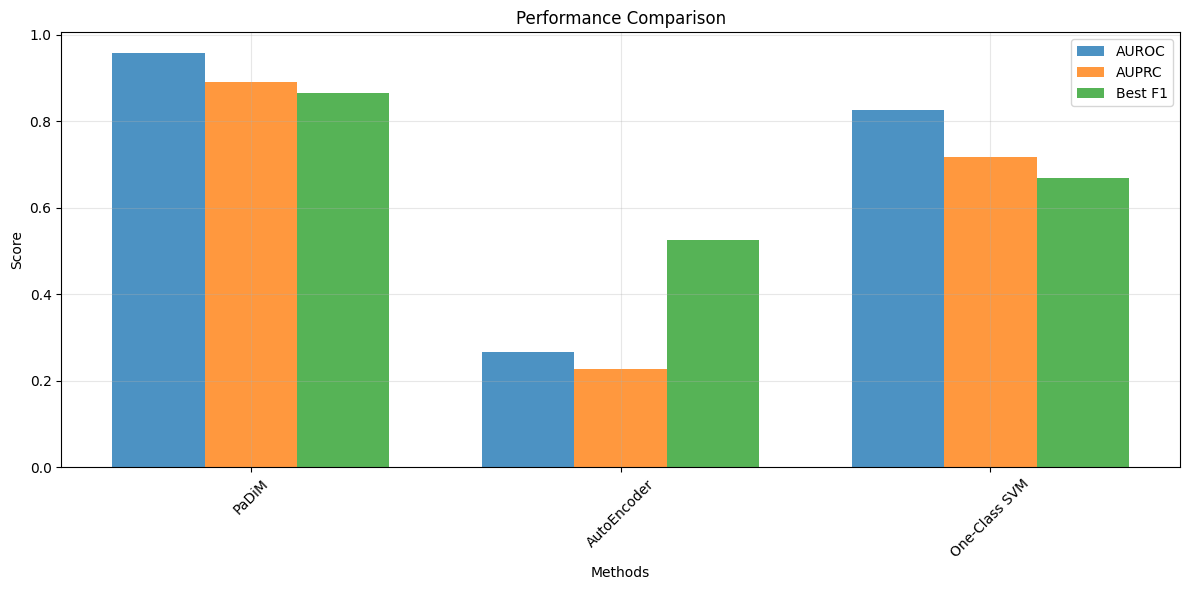

In [ ]:
system.evaluator.compare_methods()

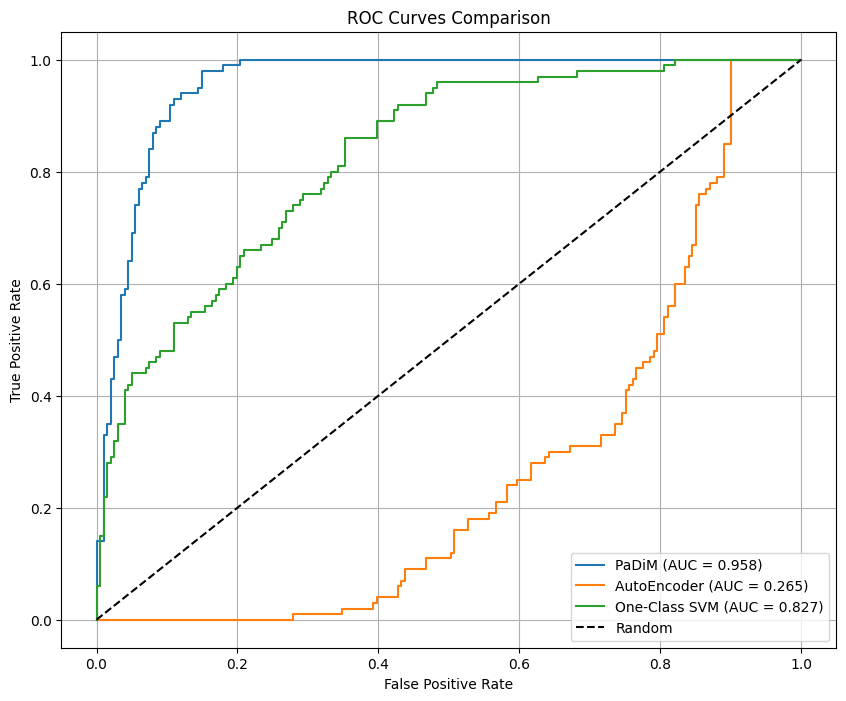

In [ ]:
system.evaluator.plot_roc_curve()

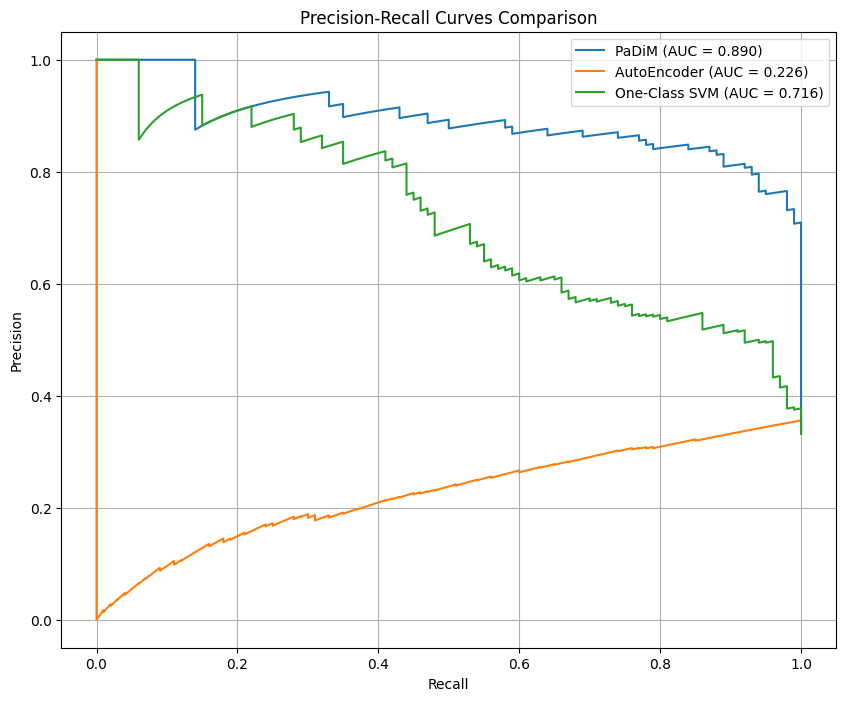

In [ ]:
system.evaluator.plot_precision_recall_curve()

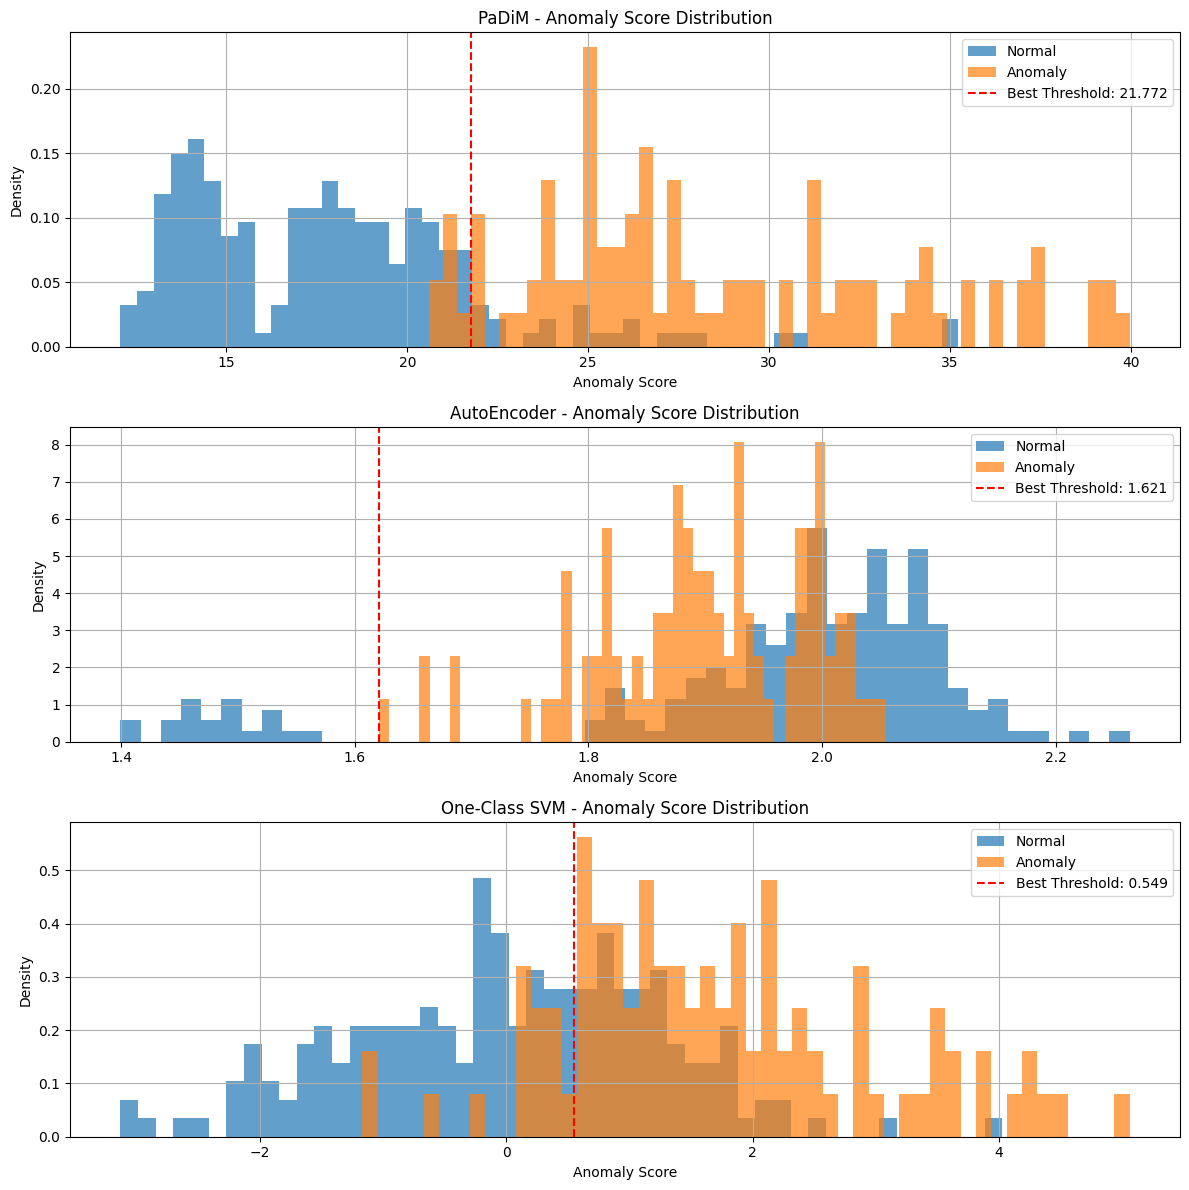

In [ ]:
system.evaluator.plot_score_distribution()

### 실시간 inference

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2
import numpy as np
import torchvision.models as models

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

import cv2
from PIL import Image
from pathlib import Path
import pickle
import json
from tqdm import tqdm
import warnings

In [ ]:
class VisADataset(Dataset):
    def __init__(self, data_path, category, transform=None, is_train=True, include_mask=False, train_ratio=0.8):
        self.data_path = Path(data_path)
        self.category = category
        self.transform = transform
        self.is_train = is_train
        self.include_mask = include_mask

        self.image_paths = []
        self.mask_paths = []
        self.labels = []
        self.defect_types = []

        category_path = self.data_path / category

        # CSV 파일에서 메타데이터 로드
        csv_path = category_path / "image_anno.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            print(f"CSV 컬럼: {df.columns.tolist()}")

            # 정상/비정상 데이터 분리
            normal_df = df[df['label'] == 'normal'].copy()
            anomaly_df = df[df['label'] != 'normal'].copy()

            if self.is_train:
                # 훈련용: 정상 데이터의 일부만 사용
                train_size = int(len(normal_df) * train_ratio)
                selected_df = normal_df.iloc[:train_size]
                print(f"훈련용 정상 데이터: {len(selected_df)}개")
            else:
                # 테스트용: 나머지 정상 데이터 + 모든 비정상 데이터
                test_normal_size = len(normal_df) - int(len(normal_df) * train_ratio)
                test_normal_df = normal_df.iloc[-test_normal_size:] if test_normal_size > 0 else pd.DataFrame()
                selected_df = pd.concat([test_normal_df, anomaly_df], ignore_index=True)
                print(f"테스트용 정상 데이터: {len(test_normal_df)}개")
                print(f"테스트용 비정상 데이터: {len(anomaly_df)}개")

            # 데이터 로드
            for _, row in selected_df.iterrows():
                # 이미지 경로 처리 (중복 경로 제거)
                image_rel_path = row['image']
                if image_rel_path.startswith(category + '/'):
                    image_path = self.data_path / image_rel_path
                else:
                    image_path = category_path / image_rel_path

                if image_path.exists():
                    self.image_paths.append(str(image_path))
                    self.labels.append(0 if row['label'] == 'normal' else 1)
                    self.defect_types.append(row['label'])

                    # 마스크 경로 처리
                    if pd.notna(row['mask']) and self.include_mask:
                        mask_rel_path = row['mask']
                        if mask_rel_path.startswith(category + '/'):
                            mask_path = self.data_path / mask_rel_path
                        else:
                            mask_path = category_path / mask_rel_path
                        self.mask_paths.append(str(mask_path) if mask_path.exists() else None)
                    else:
                        self.mask_paths.append(None)
                else:
                    print(f"이미지 파일을 찾을 수 없습니다: {image_path}")
        else:
            print("CSV 파일이 없습니다. 폴더 구조를 기반으로 데이터를 로드합니다.")
            self._load_from_folder_structure()

    def _load_from_folder_structure(self):
        """폴더 구조를 기반으로 데이터 로드 (CSV가 없는 경우)"""
        category_path = self.data_path / self.category
        images_path = category_path / "Data" / "Images"
        masks_path = category_path / "Data" / "Masks"

        if self.is_train:
            # 훈련용: 정상 이미지만 사용
            normal_path = images_path / "Normal"
            if normal_path.exists():
                for img_path in normal_path.glob("*"):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        self.image_paths.append(str(img_path))
                        self.labels.append(0)  # 정상: 0
                        self.defect_types.append('normal')
                        self.mask_paths.append(None)
        else:
            # 테스트용: 정상 + 비정상 이미지
            # 정상 이미지
            normal_path = images_path / "Normal"
            if normal_path.exists():
                for img_path in normal_path.glob("*"):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        self.image_paths.append(str(img_path))
                        self.labels.append(0)
                        self.defect_types.append('normal')
                        self.mask_paths.append(None)

            # 비정상 이미지
            anomaly_path = images_path / "Anomaly"
            if anomaly_path.exists():
                for img_path in anomaly_path.glob("*"):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        self.image_paths.append(str(img_path))
                        self.labels.append(1)  # 이상: 1
                        self.defect_types.append('anomaly')

                        # 마스크 경로 찾기
                        if self.include_mask:
                            mask_name = img_path.stem + '.png'  # 확장자를 png로 변경
                            mask_path = masks_path / "Anomaly" / mask_name
                            self.mask_paths.append(str(mask_path) if mask_path.exists() else None)
                        else:
                            self.mask_paths.append(None)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 이미지 로드
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        # 마스크 로드 (있는 경우)
        mask = None
        if self.include_mask and self.mask_paths[idx] is not None:
            try:
                mask = Image.open(self.mask_paths[idx]).convert('L')
            except:
                mask = None

        # 변환 적용
        if self.transform:
            image = self.transform(image)
            if mask is not None:
                mask_transform = transforms.Compose([
                    transforms.Resize((256, 256)),
                    transforms.ToTensor()
                ])
                mask = mask_transform(mask)

        result = {
            'image': image,
            'label': label,
            'defect_type': self.defect_types[idx]
        }

        if mask is not None:
            result['mask'] = mask

        return result

In [ ]:
def create_visa_data_loaders(data_path, category, batch_size=32, include_mask=False, train_ratio=0.8):
    """
    VisA 데이터셋용 데이터 로더 생성

    Args:
        data_path: VisA 데이터셋 경로
        category: 카테고리 이름
        batch_size: 배치 크기
        include_mask: 마스크 포함 여부
        train_ratio: 훈련 데이터 비율 (정상 데이터에서)
    """
    train_transform, test_transform = get_visa_transforms()

    train_dataset = VisADataset(
        data_path, category,
        transform=train_transform,
        is_train=True,
        include_mask=include_mask,
        train_ratio=train_ratio
    )

    test_dataset = VisADataset(
        data_path, category,
        transform=test_transform,
        is_train=False,
        include_mask=include_mask,
        train_ratio=train_ratio
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,  # Windows에서 문제가 있을 수 있으므로 낮춤
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, test_loader


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class FeatureExtractor(nn.Module):
    def __init__(self, model_name='resnet18', layers_to_extract=['layer1', 'layer2', 'layer3']):
        super(FeatureExtractor, self).__init__()

        if model_name == 'resnet18':
            self.model = models.resnet18(pretrained=True)
        elif model_name == 'resnet50':
            self.model = models.resnet50(pretrained=True)
        elif model_name == 'wide_resnet50':
            self.model = models.wide_resnet50_2(pretrained=True)
        else:
            raise ValueError(f"지원하지 않는 모델: {model_name}")

        self.layers_to_extract = layers_to_extract
        self.features = {}

        # Hook 등록
        for name, module in self.model.named_modules():
            if name in layers_to_extract:
                module.register_forward_hook(self.save_features(name))

        # 평가 모드로 설정
        self.model.eval()

        # 그래디언트 계산 비활성화
        for param in self.model.parameters():
            param.requires_grad = False

    def save_features(self, name):
        def hook(module, input, output):
            self.features[name] = output
        return hook

    def forward(self, x):
        self.features.clear()
        _ = self.model(x)
        return self.features

# Feature Extractor 초기화
feature_extractor = FeatureExtractor('wide_resnet50', ['layer2', 'layer3']).to(device)


In [ ]:
# --- PaDiM 클래스 (사용자 제공 코드, predict 수정) ---
class PaDiM:
    def __init__(self, feature_extractor, d_reduced=100, padim_patch_size=PADIM_PATCH_SIZE):
        self.feature_extractor = feature_extractor
        self.d_reduced = d_reduced
        self.padim_patch_size = padim_patch_size
        self.means = []
        self.inv_covariances = []
        self.projection_matrix = None

    def fit(self, train_loader):
        print("PaDiM 훈련 시작...")
        all_features = []
        for batch in tqdm(train_loader, desc="특징 추출 중"):
            images = batch['image'].to(device)
            with torch.no_grad():
                features = self.feature_extractor(images)
                for i in range(images.size(0)):
                    img_features = []
                    for layer_name, feat in features.items():
                        single_feat = feat[i:i+1]
                        feat_resized = F.adaptive_avg_pool2d(single_feat, (self.padim_patch_size, self.padim_patch_size))
                        feat_patches = feat_resized.permute(0, 2, 3, 1).reshape(self.padim_patch_size*self.padim_patch_size, -1)
                        img_features.append(feat_patches)
                    combined_features = torch.cat(img_features, dim=1)
                    all_features.append(combined_features)

        all_features = torch.cat(all_features, dim=0)
        print(f"전체 특징 크기: {all_features.shape}")

        if all_features.shape[1] > self.d_reduced:
            self.projection_matrix = torch.randn(all_features.shape[1], self.d_reduced).to(device)
            self.projection_matrix = F.normalize(self.projection_matrix, dim=0)
            all_features = torch.mm(all_features, self.projection_matrix)
            print(f"차원 축소 후 크기: {all_features.shape}")

        num_patches = self.padim_patch_size * self.padim_patch_size
        for patch_idx in range(num_patches):
            patch_features = all_features[patch_idx::num_patches]
            mean = torch.mean(patch_features, dim=0)
            centered_features = patch_features - mean
            cov = torch.mm(centered_features.T, centered_features) / (patch_features.shape[0] - 1)
            cov += torch.eye(cov.shape[0]).to(device) * 1e-4
            try:
                inv_cov = torch.linalg.inv(cov)
            except RuntimeError:
                inv_cov = torch.linalg.pinv(cov)
            self.means.append(mean)
            self.inv_covariances.append(inv_cov)
        print(f"PaDiM 훈련 완료! (패치 수: {len(self.means)})")

    def predict(self, images_tensor): # DataLoader 대신 이미지 텐서를 직접 받도록 수정
        """테스트 이미지 텐서에 대한 이상 점수 및 이상 맵 계산"""
        all_image_scores = []
        all_anomaly_maps = []

        with torch.no_grad():
            features = self.feature_extractor(images_tensor) # 이미지 텐서 바로 사용

            for i in range(images_tensor.size(0)):
                img_features = []
                for layer_name, feat in features.items():
                    single_feat = feat[i:i+1]
                    feat_resized = F.adaptive_avg_pool2d(single_feat, (self.padim_patch_size, self.padim_patch_size))
                    feat_patches = feat_resized.permute(0, 2, 3, 1).reshape(self.padim_patch_size*self.padim_patch_size, -1)
                    img_features.append(feat_patches)

                combined_features = torch.cat(img_features, dim=1)

                if self.projection_matrix is not None:
                    combined_features = torch.mm(combined_features, self.projection_matrix)

                patch_scores_for_image = []
                num_patches = self.padim_patch_size * self.padim_patch_size
                for patch_idx in range(num_patches):
                    diff = combined_features[patch_idx] - self.means[patch_idx]
                    mahal_dist = torch.sqrt(torch.mm(
                        torch.mm(diff.unsqueeze(0), self.inv_covariances[patch_idx]),
                        diff.unsqueeze(1)
                    )).item()
                    patch_scores_for_image.append(mahal_dist)

                all_image_scores.append(max(patch_scores_for_image))

                # 이상 맵 생성 (28x28 형태로)
                anomaly_map = torch.tensor(patch_scores_for_image).reshape(self.padim_patch_size, self.padim_patch_size).cpu().numpy()
                all_anomaly_maps.append(anomaly_map)

        return np.array(all_image_scores), np.array(all_anomaly_maps)

In [ ]:
def get_visa_transforms():
    """
    VisA 데이터셋에 적용할 이미지 변환(transform)을 반환합니다.
    실제 데이터셋과 모델에 맞게 이 부분을 수정해야 합니다.
    """
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
    ])

    # 테스트 시에는 일반적으로 Augmentation을 많이 하지 않습니다.
    test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
    ])
    return train_transform, test_transform


In [ ]:
# --- 데이터셋 경로 및 카테고리 설정 ---
# !!! 중요: 이 경로를 실제 VisA 데이터셋이 있는 경로로 수정해야 합니다 !!!
# 예시: DATA_PATH = "/path/to/your/visa_dataset"
# VisA 데이터셋이 없다면, 아래 예시처럼 직접 폴더를 만들고 소수의 이미지를 넣어 테스트할 수 있습니다.
# DATA_PATH/CATEGORY_NAME/train/good/img1.png, img2.png ...
# DATA_PATH/CATEGORY_NAME/test/good/img1.png, img2.png ...
# DATA_PATH/CATEGORY_NAME/test/anomaly_type1/img1.png, img2.png ...
DATA_PATH = "./VisA" # <--- 실제 데이터셋 경로로 변경하세요!
CATEGORY_NAME = "pcb4" # VisA 데이터셋의 카테고리 중 하나 (예: 'pcb', 'capsules' 등)
BATCH_SIZE = 8 # 메모리에 따라 조절
D_REDUCED = 100 # PaDiM의 축소된 특징 차원
IMG_SIZE = 256  # 입력 이미지 크기 (예시)
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]
# PaDiM 내부에서 특징맵을 리사이즈할 크기 (고정)
PADIM_PATCH_SIZE = 28

# 결과물 저장 경로
OUTPUT_DIR = "padim_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SAVED_MODEL_PATH = os.path.join(OUTPUT_DIR, "padim_model_state.pkl")

print(f"Data path set to: {DATA_PATH}")
print(f"Make sure you have data in the respective folders, e.g., {os.path.join(DATA_PATH, CATEGORY_NAME, 'train', 'good')}")
print("-" * 30)


# --- 모델 초기화 ---
print("FeatureExtractor 초기화 중...")
# 사용할 CNN 백본과 추출할 레이어 설정
# 예: wide_resnet50_2의 layer1, layer2, layer3 특징 사용
feature_extractor = FeatureExtractor(model_name='wide_resnet50', layers_to_extract=['layer1', 'layer2', 'layer3']).to(device)
print("PaDiM 모델 초기화 중...")
padim_model = PaDiM(feature_extractor=feature_extractor, d_reduced=D_REDUCED)

# --- 데이터 로더 생성 ---
print("데이터 로더 생성 중...")
try:
    train_loader, test_loader = create_visa_data_loaders(DATA_PATH, CATEGORY_NAME, BATCH_SIZE)

    # 훈련 데이터셋에 이미지가 있는지 확인
    if len(train_loader.dataset) == 0:
        print(f"훈련 데이터셋에 이미지가 없습니다! 경로를 확인하세요: {os.path.join(DATA_PATH, CATEGORY_NAME, 'train', 'good')}")
        # 이 경우 학습을 진행할 수 없으므로, 예외를 발생시키거나 중단할 수 있습니다.
        # raise ValueError("훈련 데이터가 비어있습니다. 학습을 진행할 수 없습니다.")
    else:
        print(f"훈련 데이터셋 크기: {len(train_loader.dataset)}")
        print(f"테스트 데이터셋 크기: {len(test_loader.dataset)}")

        # --- PaDiM 모델 학습 ---
        padim_model.fit(train_loader)

        # --- 학습된 모델 저장 ---
        print(f"학습된 PaDiM 모델을 '{SAVED_MODEL_PATH}'에 저장합니다...")
        # PaDiM 클래스 전체를 저장하거나, 필요한 attribute만 저장할 수 있습니다.
        # 여기서는 주요 attribute들을 딕셔너리 형태로 저장합니다.
        padim_state = {
            'means': padim_model.means,
            'inv_covariances': padim_model.inv_covariances,
            'projection_matrix': padim_model.projection_matrix,
            'd_reduced': padim_model.d_reduced,
            'padim_patch_size': padim_model.padim_patch_size
            # FeatureExtractor는 구조가 동일하므로 저장하지 않고 추론 시 새로 생성
        }
        with open(SAVED_MODEL_PATH, 'wb') as f:
            pickle.dump(padim_state, f)
        print("모델 저장 완료.")

except FileNotFoundError as e:
    print(f"데이터 경로 오류: {e}")
    print("DATA_PATH 및 CATEGORY_NAME을 올바르게 설정하고, 해당 경로에 이미지 파일이 있는지 확인해주세요.")
except Exception as e:
    print(f"학습 중 오류 발생: {e}")



Data path set to: ./VisA
Make sure you have data in the respective folders, e.g., ./VisA/pcb4/train/good
------------------------------
FeatureExtractor 초기화 중...
PaDiM 모델 초기화 중...
데이터 로더 생성 중...
CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
훈련 데이터셋 크기: 804
테스트 데이터셋 크기: 301
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 101/101 [00:13<00:00,  7.36it/s]


전체 특징 크기: torch.Size([630336, 1792])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
학습된 PaDiM 모델을 'padim_outputs/padim_model_state.pkl'에 저장합니다...
모델 저장 완료.


In [ ]:
# --- 저장된 PaDiM 모델 로드 함수 ---
def load_padim_model_state(filepath, feature_extractor_instance):
    if not os.path.exists(filepath):
        print(f"저장된 모델 파일이 없습니다: {filepath}")
        return None

    with open(filepath, 'rb') as f:
        padim_state = pickle.load(f)

    # 새 PaDiM 인스턴스를 만들고 상태를 로드
    loaded_model = PaDiM(feature_extractor_instance,
                           d_reduced=padim_state.get('d_reduced', 100), # 기본값 설정
                           padim_patch_size=padim_state.get('padim_patch_size', PADIM_PATCH_SIZE)) # 기본값 설정
    loaded_model.means = padim_state['means']
    loaded_model.inv_covariances = padim_state['inv_covariances']
    loaded_model.projection_matrix = padim_state['projection_matrix']

    print(f"'{filepath}'에서 PaDiM 모델 상태 로드 완료.")
    return loaded_model

# --- Gradio 추론 함수 ---
# 모델 로드는 Gradio 앱 시작 시 한 번만 수행하도록 전역 변수로 관리
gradio_feature_extractor = None
gradio_padim_model = None
_, gradio_test_transform = get_visa_transforms() # 테스트용 변환 사용

def initialize_gradio_models():
    global gradio_feature_extractor, gradio_padim_model
    if gradio_feature_extractor is None:
        print("Gradio: FeatureExtractor 초기화 중...")
        gradio_feature_extractor = FeatureExtractor(model_name='wide_resnet50', layers_to_extract=['layer1', 'layer2', 'layer3']).to(device)

    if gradio_padim_model is None:
        print("Gradio: 저장된 PaDiM 모델 로드 중...")
        gradio_padim_model = load_padim_model_state(SAVED_MODEL_PATH, gradio_feature_extractor)
        if gradio_padim_model is None:
            print("Gradio: 모델 로드 실패! 학습을 먼저 실행하거나 모델 경로를 확인하세요.")
            # Gradio 인터페이스 실행 전에 모델이 로드되었는지 확인 필요

# Gradio 앱 시작 전에 모델 초기화 시도
initialize_gradio_models()


def padim_inference_gradio(input_image_pil):
    """Gradio 인터페이스를 위한 추론 함수"""
    if gradio_padim_model is None:
        return "모델이 로드되지 않았습니다. 학습을 먼저 실행하거나 모델 경로를 확인하세요.", None, None

    # PIL 이미지를 PyTorch 텐서로 변환 및 전처리
    img_tensor = gradio_test_transform(input_image_pil).unsqueeze(0).to(device) # 배치 차원 추가

    # PaDiM 모델로 추론
    image_score, anomaly_map_array = gradio_padim_model.predict(img_tensor)

    # 결과 처리
    score = image_score[0] # 단일 이미지이므로 첫 번째 점수 사용
    anomaly_map_single = anomaly_map_array[0] # 단일 이미지의 이상 맵

    # 이상 맵 시각화 (Heatmap)
    # 0-1 범위로 정규화 후 컬러맵 적용
    anomaly_map_normalized = (anomaly_map_single - np.min(anomaly_map_single)) / \
                             (np.max(anomaly_map_single) - np.min(anomaly_map_single) + 1e-6)

    heatmap_img = cv2.applyColorMap(np.uint8(255 * anomaly_map_normalized), cv2.COLORMAP_JET)
    heatmap_img = cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB) # Matplotlib/Gradio용 RGB

    # 원본 이미지에 히트맵 오버레이 (PIL 이미지를 NumPy로 변환 후 사용)
    original_np = np.array(input_image_pil.resize((IMG_SIZE, IMG_SIZE)))
    if original_np.shape[2] == 4: # RGBA -> RGB
        original_np = original_np[..., :3]

    heatmap_resized = cv2.resize(heatmap_img, (original_np.shape[1], original_np.shape[0]))
    overlayed_image = cv2.addWeighted(original_np, 0.6, heatmap_resized, 0.4, 0)

    result_text = f"이상 점수(Anomaly Score): {score:.4f}"
    if score > 15: # 임계값 예시 (데이터와 모델에 따라 크게 달라짐, 튜닝 필요!)
        result_text += "\n판정: 비정상 (Anomaly)"
    else:
        result_text += "\n판정: 정상 (Normal)"

    return result_text, heatmap_img, overlayed_image



Gradio: FeatureExtractor 초기화 중...
Gradio: 저장된 PaDiM 모델 로드 중...
'padim_outputs/padim_model_state.pkl'에서 PaDiM 모델 상태 로드 완료.


In [ ]:
import gradio as gr

In [ ]:
# --- Gradio 인터페이스 생성 및 실행 ---
if gradio_padim_model is not None: # 모델이 성공적으로 로드된 경우에만 인터페이스 실행
    iface = gr.Interface(
        fn=padim_inference_gradio,
        inputs=gr.Image(type="pil", label="검사할 이미지 업로드"),
        outputs=[
            gr.Textbox(label="결과"),
            gr.Image(type="numpy", label="이상 맵 (Anomaly Map Heatmap)"),
            gr.Image(type="numpy", label="오버레이된 이미지 (Overlayed Image)")
        ],
        title="PaDiM 이상 탐지 시스템 (VisA Dataset)",
        description="이미지를 업로드하여 정상/비정상 여부를 판별하고 이상 영역을 확인합니다. (백본: WideResNet50)",
        examples=[ # 예제 이미지가 있다면 경로를 지정 (Gradio에서 클릭 가능)
        ] if os.path.exists(os.path.join(DATA_PATH, CATEGORY_NAME, "test")) else None # 예제 폴더가 있을 때만 추가
    )

    iface.launch(share=True) # share=True로 하면 외부에서 접속 가능한 링크 생성 (주의해서 사용)
else:
    print("-" * 50)
    print("!!! PaDiM 모델이 로드되지 않았습니다. Gradio 인터페이스를 시작할 수 없습니다. !!!")
    print("!!! 셀 7에서 모델 학습 및 저장이 성공적으로 완료되었는지, SAVED_MODEL_PATH가 올바른지 확인해주세요. !!!")
    print("-" * 50)


In [ ]:
# [실험 1] train_ratio=1.0 이면 시험 세트와 AUROC는?
from sklearn.metrics import roc_auc_score
tr_ds = VisADataset('./VisA', 'pcb4', is_train=True, train_ratio=1.0)
te_ds = VisADataset('./VisA', 'pcb4', is_train=False, train_ratio=1.0)
labels = np.array(te_ds.labels)
print('train:', len(tr_ds), '/ test:', len(te_ds), '/ test 정상:', (labels == 0).sum(), '/ test 불량:', (labels == 1).sum())
fake_scores = np.random.rand(len(labels))
print('AUROC:', roc_auc_score(labels, fake_scores))

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 1005개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 0개
테스트용 비정상 데이터: 100개
train: 1005 / test: 100 / test 정상: 0 / test 불량: 100
AUROC: nan


- **[실험 1] 내 예측**: "정상 0장 불량 100장", "정상짝이 안만들어져" → 에러가 날 것
- **결과**: 에러 없이 `nan`. 셀 [18]의 `warnings.filterwarnings('ignore')`가 경고를 숨겼다. 시험 세트가 망가져도 코드가 멈추지 않는다.
- **배운 것**: `train_ratio`는 정상만 나누는 비율이다. 불량은 항상 전부 시험으로 간다. (처음엔 "정상 80 · 불량 20 학습"으로 잘못 알았다.)

In [ ]:
# [실험 2] train_ratio 0.5 vs 0.8 -> PaDiM AUROC (같은 조건: layer2+3, seed 고정)
from sklearn.metrics import roc_auc_score
fe = FeatureExtractor('wide_resnet50', ['layer2', 'layer3']).to(device)
for r in [0.5, 0.8]:
    torch.manual_seed(0)
    tr, te = create_visa_data_loaders('./VisA', 'pcb4', batch_size=16, train_ratio=r)
    model = PaDiM(fe, d_reduced=100)
    model.fit(tr)
    scores, labels = [], []
    for b in te:
        s, _ = model.predict(b['image'].to(device))
        scores.extend(s)
        labels.extend(b['label'].numpy())
    print(f'ratio={r}  train={len(tr.dataset)}  test={len(te.dataset)}  AUROC={roc_auc_score(labels, scores):.4f}')
    del model
    torch.cuda.empty_cache()

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 502개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 503개
테스트용 비정상 데이터: 100개
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 32/32 [00:07<00:00,  4.20it/s]


전체 특징 크기: torch.Size([393568, 1536])
차원 축소 후 크기: torch.Size([393568, 100])
PaDiM 훈련 완료! (패치 수: 784)
ratio=0.5  train=502  test=603  AUROC=0.9796
CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:13<00:00,  3.66it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
ratio=0.8  train=804  test=301  AUROC=0.9738


- **[실험 2] 내 예측**: "안좋아질거같아, 학습에 많은 사진으로 보여주는게 나을거같은데"
- **결과**: 0.5 → 0.9796, 0.8 → 0.9738. 예측과 반대.
- **해석**: 비율을 바꾸면 "시험에 들어가는 정상 갯수가 많아졌지" → 시험지가 달라서 비교할 수 없다. "시험지는 고정하고 학습 장수만 바꿔"서 실험 3을 다시 했다.

In [ ]:
# [실험 3] 시험지 고정(정상 201 + 불량 100), 학습 장수만 변경
from torch.utils.data import Subset, DataLoader
from sklearn.metrics import roc_auc_score
fe = FeatureExtractor('wide_resnet50', ['layer2', 'layer3']).to(device)
tr_full, te = create_visa_data_loaders('./VisA', 'pcb4', batch_size=16, train_ratio=0.8)
for n in [50, 200, 502, 804]:
    torch.manual_seed(0)
    tr = DataLoader(Subset(tr_full.dataset, range(n)), batch_size=16, shuffle=False)
    model = PaDiM(fe, d_reduced=100)
    model.fit(tr)
    scores, labels = [], []
    for b in te:
        s, _ = model.predict(b['image'].to(device))
        scores.extend(s)
        labels.extend(b['label'].numpy())
    print(f'n_train={n}  test={len(te.dataset)}  AUROC={roc_auc_score(labels, scores):.4f}')
    del model
    torch.cuda.empty_cache()

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 4/4 [00:00<00:00,  4.08it/s]


전체 특징 크기: torch.Size([39200, 1536])
차원 축소 후 크기: torch.Size([39200, 100])
PaDiM 훈련 완료! (패치 수: 784)
n_train=50  test=301  AUROC=0.9536
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 13/13 [00:03<00:00,  3.66it/s]


전체 특징 크기: torch.Size([156800, 1536])
차원 축소 후 크기: torch.Size([156800, 100])
PaDiM 훈련 완료! (패치 수: 784)
n_train=200  test=301  AUROC=0.9641
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 32/32 [00:09<00:00,  3.47it/s]


전체 특징 크기: torch.Size([393568, 1536])
차원 축소 후 크기: torch.Size([393568, 100])
PaDiM 훈련 완료! (패치 수: 784)
n_train=502  test=301  AUROC=0.9674
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:14<00:00,  3.43it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
n_train=804  test=301  AUROC=0.9719


- **[실험 3] 내 예측**: "어느정도 이상이면 거의그대로겠지만 학습장수가 많으면 AUROC값은 클거같아", 50장은 "현저히 낮겠다"
- **결과**: 50 / 200 / 502 / 804장 → 0.9536 / 0.9641 / 0.9674 / 0.9719
- **해석**: 많을수록 오르고 증가 폭은 줄어든다(맞음). 50장도 0.95로 생각보다 버텼다(빗나감). 같은 804장인데 실험 2와 0.002 차이 → 무작위 흔들림 수준. 이후엔 시드 3개로 반복했다.

In [ ]:
# [실험 4] 학습 때 좌우 뒤집기 on/off (시험지 고정, 학습 804장, 시드 3개)
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
fe = FeatureExtractor('wide_resnet50', ['layer2', 'layer3']).to(device)
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf_flip = transforms.Compose([transforms.Resize((256, 256)), transforms.RandomHorizontalFlip(p=0.5), transforms.ToTensor(), norm])
tf_none = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), norm])
te = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=False), batch_size=16)
for name, tf in [('flip', tf_flip), ('no_flip', tf_none)]:
    tr = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf, is_train=True), batch_size=16)
    for seed in [0, 1, 2]:
        torch.manual_seed(seed)
        model = PaDiM(fe, d_reduced=100)
        model.fit(tr)
        scores, labels = [], []
        for b in te:
            s, _ = model.predict(b['image'].to(device))
            scores.extend(s)
            labels.extend(b['label'].numpy())
        print(f'{name:8s} seed={seed}  AUROC={roc_auc_score(labels, scores):.4f}')
        del model
        torch.cuda.empty_cache()

CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.38it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
flip     seed=0  AUROC=0.9632
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.35it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
flip     seed=1  AUROC=0.9530
PaDiM 훈련 시작...


...

전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
no_flip  seed=0  AUROC=0.9719
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.37it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
no_flip  seed=1  AUROC=0.9749
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.29it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
no_flip  seed=2  AUROC=0.9742


- **[실험 4] 내 예측**: "정상모습에 이상한 사진이 들어가게 될거같아 … 결국 뒤집지 않은 사진에는 약해지는거 아닌가?"
- **결과**: 뒤집기 켬 평균 0.958, 끔 평균 0.974. 범위가 겹치지 않는다.
- **해석**: PaDiM은 위치까지 정상의 정의에 포함하는데, 뒤집으면 정의 자체가 섞인다. 원본 실행의 0.9575는 이 뒤집기 때문에 깎인 점수였다.

In [ ]:
# [실험 5] 어느 층의 feature를 쓰나 (시험지 고정, 학습 804장, 뒤집기 없음, 시드 3개)
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf_none = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), norm])
tr = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=True), batch_size=16)
te = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=False), batch_size=16)
for layers in [['layer2', 'layer3'], ['layer1', 'layer2', 'layer3'], ['layer4']]:
    fe = FeatureExtractor('wide_resnet50', layers).to(device)
    for seed in [0, 1, 2]:
        torch.manual_seed(seed)
        model = PaDiM(fe, d_reduced=100)
        model.fit(tr)
        scores, labels = [], []
        for b in te:
            s, _ = model.predict(b['image'].to(device))
            scores.extend(s)
            labels.extend(b['label'].numpy())
        print(f'{"+".join(layers):22s} seed={seed}  AUROC={roc_auc_score(labels, scores):.4f}')
        del model
        torch.cuda.empty_cache()
    del fe

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.36it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
layer2+layer3          seed=0  AUROC=0.9719
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:14<00:00,  3.40it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
layer2+layer3          seed=1  AUROC=0.9749
PaDiM 훈련 시작...


...

전체 특징 크기: torch.Size([630336, 2048])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
layer4                 seed=0  AUROC=0.9295
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.37it/s]


전체 특징 크기: torch.Size([630336, 2048])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
layer4                 seed=1  AUROC=0.9255
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.29it/s]


전체 특징 크기: torch.Size([630336, 2048])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
layer4                 seed=2  AUROC=0.9300


- **[실험 5] 내 예측**: "layer1+2+3은 높고 layer4만은 위치가 뭉개져서 낮을거같아"
- **결과**: layer4만 0.928 / layer2+3 0.974 / layer1+2+3 0.979
- **해석**: 깊은 층은 "무엇"은 알지만 위치가 8×8로 뭉개진다. 28×28로 늘려도 값이 복사될 뿐 세밀해지지 않는다. 얕은 층이 미세한 위치를 준다.

In [ ]:
# [실험 6] 사진 점수 max vs mean, 거리 마할라노비스 vs 유클리드 (같은 모델 하나로 채점만 바꿈)
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf_none = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), norm])
tr = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=True), batch_size=16)
te = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=False), batch_size=16)
fe = FeatureExtractor('wide_resnet50', ['layer2', 'layer3']).to(device)
torch.manual_seed(0)
model = PaDiM(fe, d_reduced=100)
model.fit(tr)
M = torch.stack(model.means)
IC = torch.stack(model.inv_covariances)
res = {k: [] for k in ['maha_max', 'maha_mean', 'eucl_max', 'eucl_mean']}
labels = []
with torch.no_grad():
    for b in te:
        feats = fe(b['image'].to(device))
        for i in range(b['image'].size(0)):
            parts = [F.adaptive_avg_pool2d(f[i:i+1], (28, 28)).permute(0, 2, 3, 1).reshape(784, -1) for f in feats.values()]
            x = torch.cat(parts, dim=1) @ model.projection_matrix
            d = x - M
            maha = torch.sqrt(torch.einsum('pi,pij,pj->p', d, IC, d).clamp(min=0))
            eucl = d.norm(dim=1)
            res['maha_max'].append(maha.max().item())
            res['maha_mean'].append(maha.mean().item())
            res['eucl_max'].append(eucl.max().item())
            res['eucl_mean'].append(eucl.mean().item())
        labels.extend(b['label'].numpy())
for k, v in res.items():
    print(f'{k:10s} AUROC={roc_auc_score(labels, v):.4f}')

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:15<00:00,  3.39it/s]


전체 특징 크기: torch.Size([630336, 1536])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
maha_max   AUROC=0.9719
maha_mean  AUROC=0.9308
eucl_max   AUROC=0.9090
eucl_mean  AUROC=0.8004


- **[실험 6] 내 예측**: max→mean은 "불량이 차지하는칸은 매우 적겠지"라서 낮아짐 / 유클리드는 "원을 그렸을때 그 범주안에선 비슷비슷한데 사실은 특성이 다른것들"이라 조금 낮아짐
- **결과**: 마할라노비스 max 0.9719 · mean 0.9308 / 유클리드 max 0.9090 · mean 0.8004
- **해석**: 방향은 둘 다 맞았고, 유클리드 하락은 예상보다 컸다. 기준값 0.9719가 실험 4와 같아서 채점 코드도 검증됐다.

In [ ]:
# [실험 7] AutoEncoder 0.265의 원인: 출력 범위(Sigmoid 0~1) vs 입력 범위(Normalize -2~2.6)
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf_norm = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), norm])
tf_01 = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])


def loaders(tf):
    tr = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf, is_train=True), batch_size=16, shuffle=True)
    te = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf, is_train=False), batch_size=16)
    return tr, te


_, te = loaders(tf_norm)
s, y = [], []
for b in te:
    x = b['image']
    s.extend(((x - x.clamp(0, 1)) ** 2).mean(dim=(1, 2, 3)).tolist())
    y.extend(b['label'].numpy())
print(f'D 모델없이 범위밖 오차만      AUROC={roc_auc_score(y, s):.4f}')


def run(name, tf, sigmoid, epochs=20):
    torch.manual_seed(0)
    tr, te = loaders(tf)
    net = ConvAutoEncoder().to(device)
    if not sigmoid:
        net.decoder = net.decoder[:-1]
    opt = torch.optim.Adam(net.parameters(), lr=0.001)
    for ep in range(epochs):
        net.train()
        tot = 0
        for b in tr:
            x = b['image'].to(device)
            loss = F.mse_loss(net(x), x)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item()
    net.eval()
    s, y = [], []
    with torch.no_grad():
        for b in te:
            x = b['image'].to(device)
            s.extend(((net(x) - x) ** 2).mean(dim=(1, 2, 3)).cpu().tolist())
            y.extend(b['label'].numpy())
    print(f'{name}  last_loss={tot / len(tr):.4f}  AUROC={roc_auc_score(y, s):.4f}')


run('A 원본(Normalize+Sigmoid)', tf_norm, True)
run('B Sigmoid 제거          ', tf_norm, False)
run('C Normalize 제거        ', tf_01, True)

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
D 모델없이 범위밖 오차만      AUROC=0.2485
CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
A 원본(Normalize+Sigmoid)  last_loss=1.6525  AUROC=0.2708
CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
B Sigmoid 제거            last_loss=0.0411  AUROC=0.9279
CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
C Normalize 제거          last_loss=0.0026  AUROC=0.9237


- **[실험 7] 원인 추적**: 처음엔 "픽셀 값 범위 안에있으니 그려낼수있을거같은데?" → 출력 범위를 따로 보고 "아 0\~1이니까 못해" → "범위 밖에 있는것들이 오차 점수가 커"
- **내 예측**: "D는 0.27쯤, B랑 C는 0.5 넘을거같아"
- **결과**: D(모델 없이 범위 밖 양만) 0.2485 / A(원본) 0.2708 / B(Sigmoid 제거) 0.9279 / C(Normalize 제거) 0.9237
- **해석**: D ≈ A. 원래 AE는 결함이 아니라 극단 색 픽셀 양을 재고 있었다. 한 줄만 고쳐도 0.93. 그래도 PaDiM보다 낮은 건 점수를 평균으로 내서 희석되고, 픽셀을 직접 비교해 잡음이 끼기 때문이다.

In [ ]:
# [실험 8] 고친 AE(Sigmoid 제거)의 채점: mean vs max vs 흐린 뒤 max
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf_norm = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), norm])
torch.manual_seed(0)
tr = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_norm, is_train=True), batch_size=16, shuffle=True)
te = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_norm, is_train=False), batch_size=16)
net = ConvAutoEncoder().to(device)
net.decoder = net.decoder[:-1]
opt = torch.optim.Adam(net.parameters(), lr=0.001)
for ep in range(20):
    net.train()
    for b in tr:
        x = b['image'].to(device)
        loss = F.mse_loss(net(x), x)
        opt.zero_grad()
        loss.backward()
        opt.step()
net.eval()
res = {'mean': [], 'max': [], 'blur_max': []}
y = []
with torch.no_grad():
    for b in te:
        x = b['image'].to(device)
        err = ((net(x) - x) ** 2).mean(dim=1, keepdim=True)
        res['mean'].extend(err.mean(dim=(1, 2, 3)).cpu().tolist())
        res['max'].extend(err.amax(dim=(1, 2, 3)).cpu().tolist())
        res['blur_max'].extend(F.avg_pool2d(err, 9, stride=1, padding=4).amax(dim=(1, 2, 3)).cpu().tolist())
        y.extend(b['label'].numpy())
for k, v in res.items():
    print(f'{k:9s} AUROC={roc_auc_score(y, v):.4f}')

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
mean      AUROC=0.9294
max       AUROC=0.8274
blur_max  AUROC=0.9216


- **[실험 8] 내 예측**: max로 바꾸면 "오를듯"
- **결과**: mean 0.9294 / max 0.8274 / 흐린 뒤 max 0.9216. 빗나감.
- **해석**: max가 정상 사진의 잡음 픽셀 하나를 집었다. PaDiM에선 max가 이겼는데 AE에선 졌다. 채점 방식의 좋고 나쁨은 점수가 얼마나 깨끗한지에 달려 있다.

In [ ]:
# [실험 9] One-Class SVM: 학습 때 좌우 뒤집기 on/off (시드 3개)
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf_flip = transforms.Compose([transforms.Resize((256, 256)), transforms.RandomHorizontalFlip(p=0.5), transforms.ToTensor(), norm])
tf_none = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), norm])
te = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=False), batch_size=16)
y = np.array(te.dataset.labels)
fe = FeatureExtractor('wide_resnet50', ['layer2', 'layer3']).to(device)
for name, tf in [('flip', tf_flip), ('no_flip', tf_none)]:
    tr = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf, is_train=True), batch_size=16)
    for seed in [0, 1, 2]:
        torch.manual_seed(seed)
        det = OneClassSVMAnomalyDetector(fe, nu=0.1)
        det.fit(tr)
        s = det.predict(te)
        print(f'{name:8s} seed={seed}  AUROC={roc_auc_score(y, s):.4f}')

CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
One-Class SVM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:19<00:00,  2.55it/s]


One-Class SVM 훈련 완료!


특징 추출 중: 100%|██████████| 19/19 [00:07<00:00,  2.47it/s]


flip     seed=0  AUROC=0.8152
One-Class SVM 훈련 시작...


...

no_flip  seed=1  AUROC=0.8718
One-Class SVM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:19<00:00,  2.60it/s]


One-Class SVM 훈련 완료!


특징 추출 중: 100%|██████████| 19/19 [00:07<00:00,  2.48it/s]

no_flip  seed=2  AUROC=0.8718


- **[실험 9] 내 예측**: "(나) 거의 그대로일 듯, 평균내면 뒤집어도 같으니까"
- **결과**: 뒤집기 켬 0.817, 끔 0.872. 빗나감. PaDiM보다 더 크게 떨어졌다.
- **해석**: 칩 글자처럼 비대칭인 부분이 뒤집히면 CNN 특징이 달라진다. 뒤집힌 사진도 정상으로 학습되니 정상 무리가 두 덩어리가 되고 울타리가 넓어진다 → "울타리 안에 들어와서 정상으로 판정됨, 그래서 불량 놓침".
- **결론**: 이상탐지에서 증강은 "정상"의 범위를 넓힌다. 시험에 나오지 않을 변형까지 정상으로 넓히면 불량이 그 안에 숨는다. 현장 카메라가 실제로 뒤집혀 찍히면 넣는 게 맞다.

In [25]:
# [실험 10] 임계값 15 vs 23.3 vs F1 최적 (Gradio와 같은 PaDiM: layer1+2+3, 뒤집기 없음)
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf_none = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), norm])
tr = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=True), batch_size=16)
te = DataLoader(VisADataset('./VisA', 'pcb4', transform=tf_none, is_train=False), batch_size=16)
fe = FeatureExtractor('wide_resnet50', ['layer1', 'layer2', 'layer3']).to(device)
torch.manual_seed(0)
model = PaDiM(fe, d_reduced=100)
model.fit(tr)
s, y = [], []
for b in te:
    sc, _ = model.predict(b['image'].to(device))
    s.extend(sc)
    y.extend(b['label'].numpy())
s, y = np.array(s), np.array(y)
print(f'정상 점수: min={s[y == 0].min():.1f}  중앙={np.median(s[y == 0]):.1f}  max={s[y == 0].max():.1f}')
print(f'불량 점수: min={s[y == 1].min():.1f}  중앙={np.median(s[y == 1]):.1f}  max={s[y == 1].max():.1f}')
p, r, t = precision_recall_curve(y, s)
f1 = 2 * p * r / (p + r + 1e-8)
best = t[np.argmax(f1[:-1])]
for name, th in [('15', 15), ('23.3', 23.3), (f'F1최적 {best:.1f}', best)]:
    pred = (s >= th).astype(int)
    print(f'임계값 {name:12s} 불량판정 {pred.sum():3d}장  Precision={precision_score(y, pred, zero_division=0):.3f}  Recall={recall_score(y, pred):.3f}  F1={f1_score(y, pred):.3f}')

CSV 컬럼: ['image', 'label', 'mask']
훈련용 정상 데이터: 804개
CSV 컬럼: ['image', 'label', 'mask']
테스트용 정상 데이터: 201개
테스트용 비정상 데이터: 100개
PaDiM 훈련 시작...


특징 추출 중: 100%|██████████| 51/51 [00:14<00:00,  3.46it/s]


전체 특징 크기: torch.Size([630336, 1792])
차원 축소 후 크기: torch.Size([630336, 100])
PaDiM 훈련 완료! (패치 수: 784)
정상 점수: min=12.1  중앙=17.6  max=34.1
불량 점수: min=21.1  중앙=31.0  max=57.5
임계값 15           불량판정 235장  Precision=0.426  Recall=1.000  F1=0.597
임계값 23.3         불량판정 109장  Precision=0.844  Recall=0.920  F1=0.880
임계값 F1최적 23.8    불량판정 105장  Precision=0.876  Recall=0.920  F1=0.898


- **[실험 10] 내 예측**: 15를 쓰면 "recall이 늘어날거같고, precision은 내려갈거같아", 정상 점수는 "15 근처에 걸쳐 있을 듯"
- **결과**: 정상 중앙값 17.6 → 15는 정상 201장 중 135장(67%)을 불량 판정. Precision 0.426, Recall 1.000
- **해석**: 임계값은 "불량이 출하되는것이 비용이 비싸냐 혹은 멀쩡한 제품을 버리는게 비용이 비싸냐 따지고 정해야" 한다. 셀 [23]처럼 시험 세트로 고르면 "그 셋에서 잘 나올거아니야" → 정상 점수 분포로 정하는 게 맞다. 히트맵도 사진마다 min-max로 늘리면 "정상인데도 불량처럼 보일" 수 있어 고정 눈금이 필요하다.